# From Describing Data to Making Decisions
### Inferential statistics, regression and credit risk — a practical masterclass

**The one question we carry through the whole session:**
> *A lender has data on 30,000 past credit-card customers. Which applicants should it approve — and how sure can it be?*

| # | Section | The idea in one line |
|---|---------|----------------------|
| 1 | The data | What we have and what we are trying to decide |
| 2 | Descriptive vs inferential | Describing the past vs. concluding about the future |
| 3 | Sampling & confidence intervals | How wrong could our number be? |
| 4 | Hypothesis testing | Is this pattern real, or just luck? |
| 5 | Linear regression | Explaining a number (monthly spending) |
| 6 | Logistic regression | Predicting a yes/no (default) |
| 7 | Talking to stakeholders | Turning output into a decision |

**How to use this notebook:** run cells top to bottom. Every section ends with a *"Say it in plain English"* box — that is the sentence you would tell a manager.

## 0. Setup

In [1]:
import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:  # Colab: install what is missing. Local users can ignore this cell.
    %pip install -q statsmodels ucimlrepo xlrd

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, r2_score

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(42)   # fixed seed so everyone sees the same random draws

def fmt_p(p):
    # report p-values the way papers do: never "p = 0"
    return "< 0.001" if p < 0.001 else f"{p:.3f}"

**Helper: load & clean the data.** This cell is plumbing (it finds the file, fixes a few odd category codes, adds friendly columns). Skim it, don't study it — it is the same code the Streamlit app uses.

In [3]:
from pathlib import Path

TARGET = "default"

PAY_COLS = [f"PAY_{i}" for i in range(1, 7)]
BILL_COLS = [f"BILL_AMT{i}" for i in range(1, 7)]
PAYAMT_COLS = [f"PAY_AMT{i}" for i in range(1, 7)]
RAW_FEATURES = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE"] + PAY_COLS + BILL_COLS + PAYAMT_COLS

SEX_LABELS = {1: "Male", 2: "Female"}
EDU_LABELS = {1: "Graduate school", 2: "University", 3: "High school", 4: "Other"}
MARRIAGE_LABELS = {1: "Married", 2: "Single", 3: "Other"}

_FILE_PATTERNS = [
    "default of credit card clients*.xls*",
    "default_of_credit_card_clients*.xls*",
    "UCI_Credit_Card*.csv",
    "credit_default*.csv",
]

INSTRUCTIONS = """Could not find the credit card default dataset.

Download it (free, open licence) from the UCI repository:
  https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients
and put the file in the data/ folder (or upload it to Colab's file panel).
Accepted names: 'default of credit card clients.xls' or 'UCI_Credit_Card.csv'.
"""


def _search_dirs(data_dir=None):
    here = Path(__file__).resolve().parents[2] if "__file__" in globals() else Path.cwd()
    dirs = [Path(data_dir)] if data_dir else []
    dirs += [here / "data", Path.cwd() / "data", Path.cwd().parent / "data", Path.cwd()]
    return dirs


def _find_file(data_dir=None):
    for d in _search_dirs(data_dir):
        for pattern in _FILE_PATTERNS:
            hits = sorted(d.glob(pattern)) if d.exists() else []
            if hits:
                return hits[0]
    return None


def read_raw(source, suffix=None) -> pd.DataFrame:
    """Read the raw UCI file (.xls/.xlsx/.csv) from a path or an uploaded file object."""
    suffix = (suffix or Path(str(getattr(source, "name", source))).suffix).lower()
    if suffix == ".csv":
        return pd.read_csv(source)
    # The UCI Excel file has a row of X1..X23 labels above the real header.
    df = pd.read_excel(source, header=1, engine='xlrd')
    if "LIMIT_BAL" not in df.columns:
        if hasattr(source, "seek"):
            source.seek(0)
        df = pd.read_excel(source, header=0, engine='xlrd')
    return df


def _from_ucimlrepo() -> pd.DataFrame:
    from ucimlrepo import fetch_ucirepo  # pip install ucimlrepo

    ds = fetch_ucirepo(id=350)
    X, y = ds.data.features.copy(), ds.data.targets.copy()
    if list(X.columns)[:2] == ["X1", "X2"]:
        X.columns = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE"] + [
            "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"
        ] + [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
    X[TARGET] = y.iloc[:, 0].values
    return X


def clean(raw: pd.DataFrame) -> pd.DataFrame:
    """Standardise column names and fix the undocumented category codes."""
    df = raw.copy()
    df.columns = [str(c).strip() for c in df.columns]
    df = df.rename(columns={
        "PAY_0": "PAY_1",
        "default payment next month": TARGET,
        "default.payment.next.month": TARGET,
    })
    df = df.drop(columns=[c for c in ["ID"] if c in df.columns])
    missing = set(RAW_FEATURES + [TARGET]) - set(df.columns)
    if missing:
        raise ValueError(f"Dataset is missing expected columns: {sorted(missing)}")
    df = df[RAW_FEATURES + [TARGET]].astype(float).round().astype(int)
    # The data dictionary lists education 1-4 and marriage 1-3, but the file also
    # contains 0, 5, 6 (education) and 0 (marriage). Fold them into "Other".
    df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
    df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})
    return df.reset_index(drop=True)


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add readable labels and a few analyst-friendly engineered columns."""
    df = df.copy()
    df["sex_label"] = df["SEX"].map(SEX_LABELS)
    df["edu_label"] = df["EDUCATION"].map(EDU_LABELS)
    df["marriage_label"] = df["MARRIAGE"].map(MARRIAGE_LABELS)
    df["female"] = (df["SEX"] == 2).astype(int)
    df["limit_k"] = df["LIMIT_BAL"] / 1000  # credit limit in thousands
    df["limit_100k"] = df["limit_k"] / 100  # per-100k scale keeps odds ratios readable
    # PAY_x codes: -2 no consumption, -1 paid in full, 0 revolving, 1..9 months late.
    df["late_1"] = df["PAY_1"].clip(lower=0)  # months late on the latest bill
    df["max_late"] = df[PAY_COLS].clip(lower=0).max(axis=1)
    df["n_late_months"] = (df[PAY_COLS] > 0).sum(axis=1)
    df["utilization"] = (df["BILL_AMT1"] / df["LIMIT_BAL"]).clip(0, 1.5)
    df["avg_bill"] = df[BILL_COLS].mean(axis=1) / 1000  # thousands
    df["avg_payment"] = df[PAYAMT_COLS].mean(axis=1) / 1000
    owed = df["BILL_AMT1"].where(df["BILL_AMT1"] > 0)
    df["paid_ratio"] = (df["PAY_AMT1"] / owed).clip(0, 1).fillna(1.0)
    return df


def looks_official(df: pd.DataFrame) -> bool:
    """True if the data matches the published dataset: 30,000 rows, 22.12% defaults."""
    return len(df) == 30_000 and abs(df[TARGET].mean() - 0.2212) < 0.001


def load_credit_data(data_dir=None, allow_download=True, allow_synthetic=False):
    """Return (dataframe, source_description).

    Order tried: local file in data/ -> download via `ucimlrepo` -> synthetic
    practice data (only if allow_synthetic=True).
    """
    path = _find_file(data_dir)
    if path is not None:
        return add_features(clean(read_raw(path))), f"local file: {path.name}"
    if allow_download:
        try:
            return add_features(clean(_from_ucimlrepo())), "UCI repository (via ucimlrepo)"
        except Exception as exc:  # no network, package missing, etc.
            reason = f"{type(exc).__name__}: {exc}"
    else:
        reason = "download disabled"
    if allow_synthetic:
        from .synthetic import make_synthetic

        return add_features(clean(make_synthetic())), "SYNTHETIC practice data (not real)"
    raise FileNotFoundError(INSTRUCTIONS + f"\n(Automatic download also failed: {reason})")

In [4]:
df, source = load_credit_data()
print("Data source     :", source)
print("Official UCI data?", looks_official(df), "(True = 30,000 rows and a 22.12% default rate)")
print("Rows, columns   :", df.shape)

Data source     : local file: default of credit card clients.xls
Official UCI data? True (True = 30,000 rows and a 22.12% default rate)
Rows, columns   : (30000, 37)


## 1. The data and the decision

Each row is one credit-card customer (Taiwan, 2005 — a public research dataset). We know their **credit limit, age, education, marital status**, whether they paid the last six bills **on time**, how big those bills were, and how much they paid. The column `default` says whether they **failed to pay the next month's bill** (1 = yes).

> **Kenyan angle:** swap "credit card" for a digital loan, a SACCO loan or a buy-now-pay-later plan. The question is identical: *who will repay?*

| Column | Meaning |
|---|---|
| `limit_k` | Credit limit (thousands of NT$) |
| `late_1` | Months late on the most recent bill (0 = not late) |
| `utilization` | Latest bill ÷ credit limit (how "maxed out" they are) |
| `paid_ratio` | Share of the latest bill they actually paid |
| `avg_bill` | Average monthly bill over 6 months (thousands) |
| `default` | **Target:** 1 = missed next payment |

In [5]:
df[["limit_k", "AGE", "edu_label", "late_1", "utilization", "paid_ratio", "avg_bill", "default"]].head()

,limit_k,AGE,edu_label,late_1,utilization,paid_ratio,avg_bill,default
0,20.0,24,University,2,0.195650,0.000000,1.284000,1
1,120.0,26,University,0,0.022350,0.000000,2.846167,1
2,90.0,34,University,0,0.324878,0.051917,16.942167,0
3,50.0,37,University,0,0.939800,0.042562,38.555667,0
4,50.0,57,University,0,0.172340,0.232099,18.223167,0


In [6]:
print(f"Overall default rate: {df['default'].mean():.1%}")
df["default"].value_counts().rename({0: "repaid", 1: "defaulted"})

Overall default rate: 22.1%


default
repaid       23364
defaulted     6636
Name: count, dtype: int64

## 2. Descriptive vs inferential statistics

**Analogy — the match report vs the transfer decision.**
*Descriptive* stats are the match report: "we had 58% possession and 4 shots on target." It tells you exactly what happened.
*Inferential* stats are the scout deciding whether to sign the player: "based on these 10 matches, will he perform next season?" You are going **beyond the data you hold**, and you must admit you might be wrong.

| | Descriptive | Inferential |
|---|---|---|
| Question | What happened in *this* data? | What is true about the *wider* population / the future? |
| Output | Averages, counts, charts | Confidence intervals, p-values, predictions |
| Certainty | Exact | Always comes with uncertainty |

In [7]:
# DESCRIPTIVE: summarise exactly what is in the table
df[["limit_k", "AGE", "utilization", "late_1", "avg_bill"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
limit_k,30000.0,167.48,129.75,10.00,50.00,140.00,240.00,1000.00
AGE,30000.0,35.49,9.22,21.00,28.00,34.00,41.00,79.00
utilization,30000.0,0.42,0.40,0.00,0.02,0.31,0.83,1.50
late_1,30000.0,0.36,0.76,0.00,0.00,0.00,0.00,8.00
avg_bill,30000.0,44.98,63.26,-56.04,4.78,21.05,57.10,877.31


In [8]:
# DESCRIPTIVE: compare defaulters and non-defaulters
df.groupby("default")[["limit_k", "AGE", "utilization", "late_1", "paid_ratio"]].mean().round(2).rename(index={0: "repaid", 1: "defaulted"})

,limit_k,AGE,utilization,late_1,paid_ratio
default,,,,,
repaid,178.10,35.42,0.40,0.20,0.33
defaulted,130.11,35.73,0.49,0.92,0.26


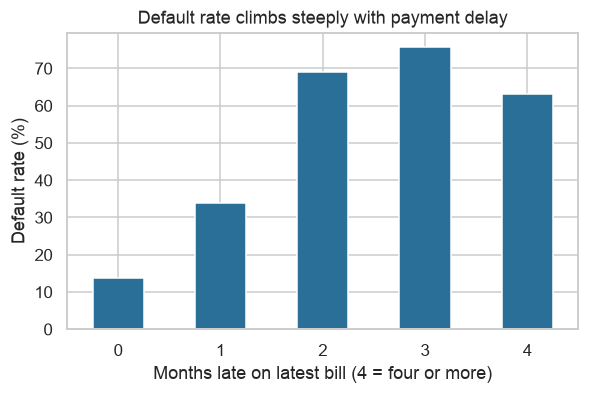

,default_rate,customers
months_late,,
0,0.138,23182
1,0.339,3688
2,0.691,2667
3,0.758,322
4,0.631,141


In [9]:
by_late = (df.assign(months_late=df["late_1"].clip(upper=4))
             .groupby("months_late")["default"].agg(default_rate="mean", customers="size"))
ax = by_late["default_rate"].mul(100).plot.bar(color="#2a6f97", figsize=(6, 3.5), rot=0)
ax.set_xlabel("Months late on latest bill (4 = four or more)")
ax.set_ylabel("Default rate (%)")
ax.set_title("Default rate climbs steeply with payment delay")
plt.show()
by_late.round(3)

Those tables are **descriptive** — they are true for these 30,000 customers. But the lender does not care about *these* customers; they care about **next month's applicants**. To move from "what happened" to "what we should expect", we need to reason about **uncertainty**. That is the rest of the session.

> *Descriptive statistics tell you what happened. Inferential statistics tell you what you can safely conclude — and how much you might be wrong.*

## 3. Sampling, confidence intervals and uncertainty

**Analogy — tasting the soup.** You don't drink the whole pot to check the salt; you stir and taste **one spoonful**. If the pot is well mixed, the spoonful represents the pot. But two spoonfuls will taste *slightly* different — that difference is **sampling variation**, and it is unavoidable.

For teaching, we pretend our 30,000 customers are **the whole population** (so we know the truth), then act like analysts who only see a small sample. Real life is the reverse: you only ever see the sample.

In [10]:
population = df
y_all = population["default"].to_numpy()
true_rate = y_all.mean()
true_limit = population["limit_k"].mean()
print(f"TRUTH (the whole population): default rate = {true_rate:.2%}, mean limit = {true_limit:.1f}k")

# One analyst, one sample of 200 customers
sample = population.sample(200, random_state=1)
print(f"This analyst's sample of 200 says: default rate = {sample['default'].mean():.2%}, mean limit = {sample['limit_k'].mean():.1f}k")

TRUTH (the whole population): default rate = 22.12%, mean limit = 167.5k
This analyst's sample of 200 says: default rate = 20.50%, mean limit = 178.5k


The analyst's number is close but not exact. **How far off could it be?** Let's see what happens if 1,000 different analysts each draw their own sample.

### 3.1 The sampling distribution

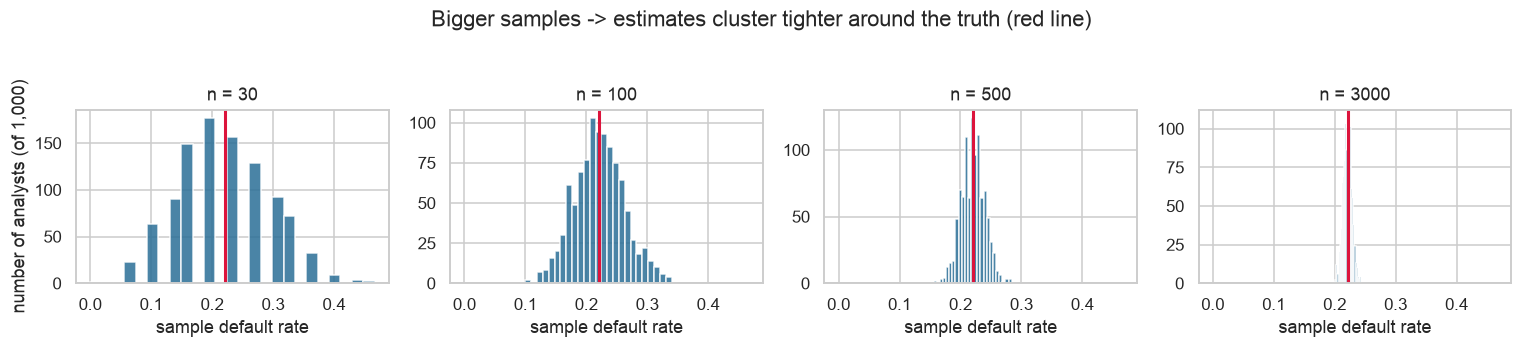

,sample_size,observed_spread (std of estimates),formula: sqrt(p(1-p)/n)
0,30,0.0759,0.0758
1,100,0.0425,0.0415
2,500,0.0192,0.0186
3,3000,0.0073,0.0076


In [11]:
sizes = [30, 100, 500, 3000]
draws = {n: np.array([rng.choice(y_all, n, replace=False).mean() for _ in range(1000)]) for n in sizes}

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharex=True)
for ax, n in zip(axes, sizes):
    ax.hist(draws[n], bins=25, color="#2a6f97", alpha=0.85)
    ax.axvline(true_rate, color="crimson", lw=2)
    ax.set_title(f"n = {n}")
    ax.set_xlabel("sample default rate")
axes[0].set_ylabel("number of analysts (of 1,000)")
fig.suptitle("Bigger samples -> estimates cluster tighter around the truth (red line)", y=1.05)
plt.tight_layout(); plt.show()

table = pd.DataFrame({
    "sample_size": sizes,
    "observed_spread (std of estimates)": [draws[n].std() for n in sizes],
    "formula: sqrt(p(1-p)/n)": [np.sqrt(true_rate * (1 - true_rate) / n) for n in sizes],
}).round(4)
table

The "spread" is the **standard error**. The formula matches what we observed, and shows the square-root law: **to halve your uncertainty you need 4x the data**, not 2x.

### 3.2 A confidence interval — a range, not a point

**Analogy — the weather forecast.** "Tomorrow: 24 C" is a lie of precision. "Between 21 and 27 C" is honest. A 95% confidence interval (CI) is the honest version of an estimate.

In [12]:
n = len(sample)
k = sample["default"].sum()
lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
print(f"Default rate: {k/n:.1%}  (95% CI: {lo:.1%} to {hi:.1%})")

s = sample["limit_k"]
lo_m, hi_m = stats.t.interval(0.95, len(s) - 1, loc=s.mean(), scale=stats.sem(s))
print(f"Mean limit  : {s.mean():.1f}k (95% CI: {lo_m:.1f}k to {hi_m:.1f}k)")
print(f"\nDoes the truth sit inside? default rate: {lo <= true_rate <= hi} | mean limit: {lo_m <= true_limit <= hi_m}")

Default rate: 20.5%  (95% CI: 15.5% to 26.6%)
Mean limit  : 178.5k (95% CI: 161.3k to 195.7k)

Does the truth sit inside? default rate: True | mean limit: True


### 3.3 What does "95%" actually mean?

It does **not** mean "there is a 95% chance the truth is in *this* interval". It means: **if 100 analysts each built an interval this way, about 95 of their intervals would catch the truth.** The method is right 95% of the time. Let's verify by brute force.

In [13]:
def coverage_experiment(conf, n=200, reps=1000):
    hits, widths, intervals = 0, [], []
    for _ in range(reps):
        k = rng.choice(y_all, n, replace=False).sum()
        lo, hi = proportion_confint(k, n, alpha=1 - conf, method="wilson")
        hits += lo <= true_rate <= hi
        widths.append(hi - lo)
        intervals.append((lo, hi))
    return hits / reps, np.mean(widths), intervals

rows, keep = [], None
for conf in [0.80, 0.90, 0.95, 0.99]:
    cov, width, ints = coverage_experiment(conf)
    rows.append({"confidence level": conf, "intervals that caught the truth": f"{cov:.1%}", "average width": round(width, 3)})
    if conf == 0.95:
        keep = ints
pd.DataFrame(rows)

,confidence level,intervals that caught the truth,average width
0,0.80,81.5%,0.075
1,0.90,90.9%,0.096
2,0.95,95.1%,0.114
3,0.99,99.0%,0.149


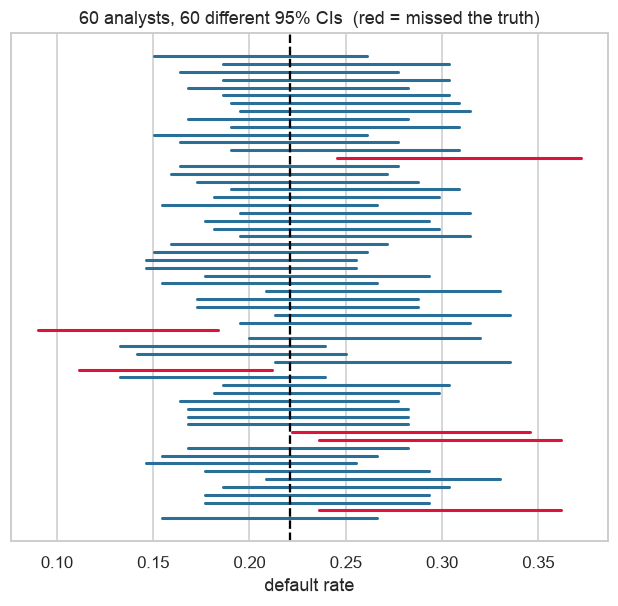

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
for i, (lo, hi) in enumerate(keep[:60]):
    caught = lo <= true_rate <= hi
    ax.plot([lo, hi], [i, i], color="#2a6f97" if caught else "crimson", lw=2)
ax.axvline(true_rate, color="black", ls="--")
ax.set_yticks([]); ax.set_xlabel("default rate")
ax.set_title("60 analysts, 60 different 95% CIs  (red = missed the truth)")
plt.show()

Notice the trade-off in the table: **more confidence = wider interval**. A 99% interval is safer but less useful ("the default rate is between 5% and 60%" is 100% right and 100% useless).

### 3.4 Shrinking the interval: how much data do you need?

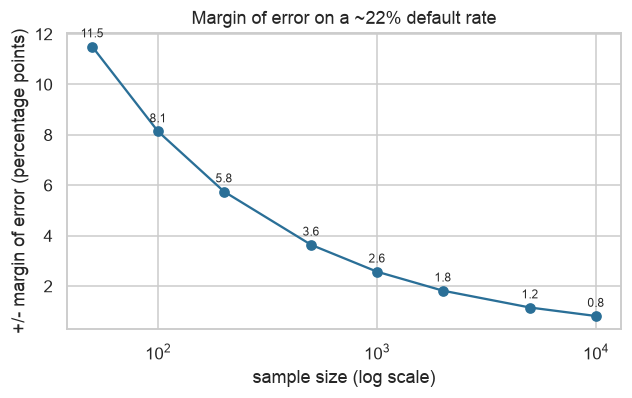

In [15]:
ns = np.array([50, 100, 200, 500, 1000, 2000, 5000, 10000])
half_width = 1.96 * np.sqrt(true_rate * (1 - true_rate) / ns)
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(ns, half_width * 100, "o-", color="#2a6f97")
ax.set_xscale("log"); ax.set_xlabel("sample size (log scale)"); ax.set_ylabel("+/- margin of error (percentage points)")
ax.set_title("Margin of error on a ~22% default rate")
for x, h in zip(ns, half_width):
    ax.annotate(f"{h*100:.1f}", (x, h * 100), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)
plt.show()

**Business use:** a lender pilots a new product on 200 customers and sees an 18% default rate versus a 22% portfolio average. The margin of error at n=200 is about +/-5 points (range roughly 13% to 24%), so **this pilot cannot tell 18% from 22%** — it needs a bigger pilot. That is the practical power of a CI.

### 3.5 No formula? Bootstrap it

For some statistics (the median, a ratio, a model metric) there is no tidy formula. **Bootstrapping** re-samples *your own sample* with replacement many times and looks at the spread. **Analogy:** photocopying your one handful of marbles and drawing from the photocopies to see how much handfuls vary.

In [16]:
s = population["limit_k"].sample(300, random_state=2).to_numpy()
boot_medians = np.array([np.median(rng.choice(s, len(s), replace=True)) for _ in range(5000)])
lo, hi = np.percentile(boot_medians, [2.5, 97.5])
print(f"Sample median limit: {np.median(s):.0f}k   bootstrap 95% CI: {lo:.0f}k to {hi:.0f}k   (true median: {population['limit_k'].median():.0f}k)")

Sample median limit: 140k   bootstrap 95% CI: 110k to 170k   (true median: 140k)


> **Say it in plain English:** *Our estimate isn't a single number — it's a range. A 95% CI means the method captures the truth 95% of the time. Want a tighter range? Collect more data (4x the data halves the width), or accept less confidence.*

## 4. Hypothesis testing: is it real or just luck?

**Analogy — the courtroom.** The defendant (the "boring explanation", **H0**) is *presumed innocent*: "there is no difference." We only convict if the evidence would be **very surprising** if the defendant were innocent. The **p-value** is the surprise meter:

> **p-value = the probability of seeing a difference at least this big *if nothing were really going on*.**

Small p (typically < 0.05, the **significance level alpha**) -> "too surprising to be luck" -> reject H0. It is **not** the probability that H0 is true, and it says **nothing** about how *big* or *important* the effect is.

| Step | Example |
|---|---|
| 1. State H0 / H1 | H0: defaulters and non-defaulters have the same average limit. H1: they differ |
| 2. Pick alpha | 0.05 |
| 3. Choose the test | Comparing two averages -> Welch t-test |
| 4. Get the p-value | Below |
| 5. Decide **and** report effect size + CI | Never p alone |

### 4.1 Test A — do defaulters have different credit limits? (numeric vs. two groups)

In [17]:
g0 = df.loc[df["default"] == 0, "limit_k"]
g1 = df.loc[df["default"] == 1, "limit_k"]

t_stat, p_limit = stats.ttest_ind(g1, g0, equal_var=False)          # Welch t-test
diff_limit = g1.mean() - g0.mean()
se = np.sqrt(g1.var(ddof=1) / len(g1) + g0.var(ddof=1) / len(g0))
ci_limit = (diff_limit - 1.96 * se, diff_limit + 1.96 * se)
pooled_sd = np.sqrt(((len(g1) - 1) * g1.var(ddof=1) + (len(g0) - 1) * g0.var(ddof=1)) / (len(g1) + len(g0) - 2))
d_limit = diff_limit / pooled_sd                                     # Cohen's d = effect size
u_stat, p_mw = stats.mannwhitneyu(g1, g0, alternative="two-sided")   # robust to skew / outliers

print(f"Mean limit  defaulted: {g1.mean():.1f}k   repaid: {g0.mean():.1f}k")
print(f"Difference (defaulted - repaid): {diff_limit:.1f}k   95% CI: {ci_limit[0]:.1f}k to {ci_limit[1]:.1f}k")
print(f"Welch t-test p-value: {fmt_p(p_limit)}   |   Mann-Whitney p-value: {fmt_p(p_mw)}")
print(f"Cohen's d (effect size): {d_limit:.2f}   (negative = defaulters have LOWER limits; size: 0.2 small, 0.5 medium, 0.8 large)")

Mean limit  defaulted: 130.1k   repaid: 178.1k
Difference (defaulted - repaid): -48.0k   95% CI: -51.2k to -44.7k
Welch t-test p-value: < 0.001   |   Mann-Whitney p-value: < 0.001
Cohen's d (effect size): -0.37   (negative = defaulters have LOWER limits; size: 0.2 small, 0.5 medium, 0.8 large)


**Reading it:** the p-value is tiny, so this gap is not luck. The CI tells us the *size* (defaulters have limits roughly this much lower), and Cohen's d puts that size on a standard scale so we can judge whether it matters. Two tests agreeing (parametric and rank-based) makes the conclusion sturdier.

**Careful with the wording:** lower limits are *associated* with default. The lender may well have *set* lower limits for customers it already judged risky. Hypothesis tests show association, not cause.

### 4.2 Test B — does the default rate differ between men and women? (two proportions)

In [18]:
ct = pd.crosstab(df["sex_label"], df["default"])
counts, nobs = ct[1].to_numpy(), ct.sum(axis=1).to_numpy()
z_stat, p_sex = proportions_ztest(counts, nobs)
rates = counts / nobs
diff_sex_pp = (rates[1] - rates[0]) * 100   # Male minus Female, in percentage points
se_sex = np.sqrt((rates * (1 - rates) / nobs).sum()) * 100
print(pd.DataFrame({"customers": nobs, "defaulted": counts, "default_rate": rates.round(4)}, index=ct.index))
print(f"\nMale - Female difference: {diff_sex_pp:.1f} percentage points  (95% CI: {diff_sex_pp-1.96*se_sex:.1f} to {diff_sex_pp+1.96*se_sex:.1f})")
print(f"p-value: {fmt_p(p_sex)}")

           customers  defaulted  default_rate
sex_label                                    
Female         18112       3763        0.2078
Male           11888       2873        0.2417

Male - Female difference: 3.4 percentage points  (95% CI: 2.4 to 4.4)
p-value: < 0.001


### 4.3 Test C — does default depend on education? (two categories vs. a category with many levels)

In [19]:
ct_edu = pd.crosstab(df["edu_label"], df["default"])
chi2, p_edu, dof, expected = stats.chi2_contingency(ct_edu)
cramers_v = np.sqrt(chi2 / (len(df) * (min(ct_edu.shape) - 1)))
out = ct_edu.assign(default_rate=(ct_edu[1] / ct_edu.sum(axis=1)).round(3))
print(out)
print(f"\nChi-square p-value: {fmt_p(p_edu)}   Cramer's V (effect size, 0-1): {cramers_v:.3f}")

default              0     1  default_rate
edu_label                                 
Graduate school   8549  2036         0.192
High school       3680  1237         0.252
Other              435    33         0.071
University       10700  3330         0.237

Chi-square p-value: < 0.001   Cramer's V (effect size, 0-1): 0.073


### 4.4 The big-data trap: *significant* is not the same as *important*

**Analogy — a very sensitive bathroom scale.** A scale accurate to 1 gram will tell you, "with overwhelming certainty, you gained 3 grams." True, statistically detectable, and utterly irrelevant to your health.

With 30,000 rows, even small differences look "significant". Let's keep the *same* tiny real difference (male vs. female default rate) and just vary the **sample size**.

In [20]:
def sex_pvalue(n):
    s = df.sample(n, random_state=int(rng.integers(1_000_000_000)))
    g = s.groupby("female")["default"].agg(["sum", "count"])
    return proportions_ztest(g["sum"].to_numpy(), g["count"].to_numpy())[1]

rows = []
for n in [500, 2000, 5000, 15000]:
    ps = np.array([sex_pvalue(n) for _ in range(200)])
    rows.append({"sample size": n, "median p-value": round(np.median(ps), 4), "% of samples with p < 0.05": f"{(ps < 0.05).mean():.0%}"})
print(f"The effect is the same in every row: about {abs(diff_sex_pp):.1f} percentage points.")
pd.DataFrame(rows)

The effect is the same in every row: about 3.4 percentage points.


,sample size,median p-value,% of samples with p < 0.05
0,500,0.3341,17%
1,2000,0.0446,52%
2,5000,0.0036,83%
3,15000,0.0000,100%


Same effect, different verdicts. That is why we **always** report the *size* of the effect and a CI, and ask *"is a difference this big worth acting on?"* The credit-limit gap (Test A) is many times bigger, in effect-size terms, than the gender gap.

### 4.5 A p-value from first principles: the permutation test

No formulas — just shuffle. If limits had nothing to do with default, then **shuffling the default labels** shouldn't change anything. Shuffle thousands of times, and see how often luck alone produces a gap as big as the real one.

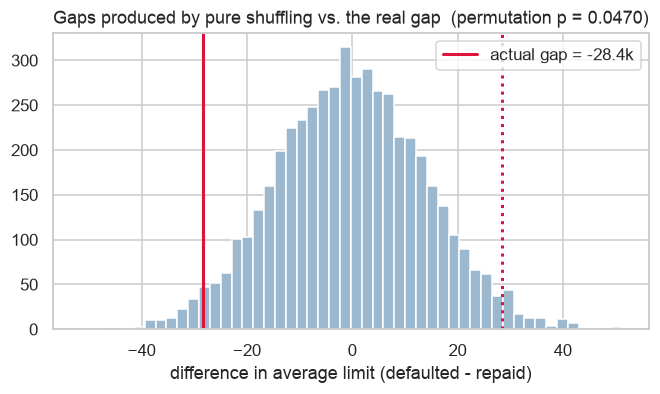

In [21]:
small = df.sample(400, random_state=7)
vals, labels = small["limit_k"].to_numpy(), small["default"].to_numpy()
observed = vals[labels == 1].mean() - vals[labels == 0].mean()

perm = np.empty(5000)
for i in range(perm.size):
    shuffled = rng.permutation(labels)
    perm[i] = vals[shuffled == 1].mean() - vals[shuffled == 0].mean()
p_perm = (np.sum(np.abs(perm) >= abs(observed)) + 1) / (perm.size + 1)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(perm, bins=50, color="#9bb8cf")
ax.axvline(observed, color="crimson", lw=2, label=f"actual gap = {observed:.1f}k")
ax.axvline(-observed, color="crimson", lw=2, ls=":")
ax.set_title(f"Gaps produced by pure shuffling vs. the real gap  (permutation p = {p_perm:.4f})")
ax.set_xlabel("difference in average limit (defaulted - repaid)"); ax.legend()
plt.show()

### 4.6 The multiple-testing trap: test enough things and something "works"

**Analogy — flipping coins until you get five heads in a row and claiming you're psychic.** Run 200 tests on **pure random noise** and see what happens at alpha = 0.05.

In [22]:
y_bool = df["default"].to_numpy() == 1
noise_p = []
for _ in range(200):
    noise = rng.normal(size=len(df))          # a column of pure random numbers
    noise_p.append(stats.ttest_ind(noise[y_bool], noise[~y_bool]).pvalue)
noise_p = np.array(noise_p)
print(f"200 tests on pure noise -> {int((noise_p < 0.05).sum())} 'significant' results at p < 0.05  (expected about 10)")
print(f"With a Bonferroni correction (alpha / 200 = {0.05/200:.5f}) -> {int((noise_p < 0.05/200).sum())} 'discoveries'")

200 tests on pure noise -> 15 'significant' results at p < 0.05  (expected about 10)
With a Bonferroni correction (alpha / 200 = 0.00025) -> 1 'discoveries'


> **Say it in plain English:** *We asked "is this gap just luck?" For credit limits the answer is clearly no, and the gap is substantial. For gender any gap is much smaller — decide with the size, not just the p-value. And if you test many things, expect some false alarms.*

**Which test when? (cheat sheet)**

| Your question | Data | Test |
|---|---|---|
| Do 2 groups differ on an average? | numeric vs 2 groups | Welch t-test (Mann-Whitney if very skewed) |
| Do 2 groups differ on a rate? | yes/no vs 2 groups | Two-proportion z-test |
| Is a category related to yes/no outcome? | category vs yes/no | Chi-square test |
| Are 2 numbers related? | numeric vs numeric | Correlation / regression |

## 5. Linear regression: explaining a number

**Analogy — a pricing rule of thumb.** An estate agent says: "Each extra bedroom adds about KES 500,000, each 10 minutes closer to town adds KES 300,000." Linear regression *learns* those rules from data: an outcome = a baseline + an amount for each factor, **holding the others fixed**.

**Business question:** *what drives how much a customer typically has on their card each month* (`avg_bill`, in thousands)? This helps with revenue forecasting and limit-setting.

### 5.1 Simple regression (one predictor)

In [23]:
m1 = smf.ols("avg_bill ~ limit_k", data=df).fit()
print(m1.summary().tables[1])
print(f"\nR-squared: {m1.rsquared:.3f}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     20.3121      0.569     35.726      0.000      19.198      21.426
limit_k        0.1473      0.003     54.877      0.000       0.142       0.153

R-squared: 0.091


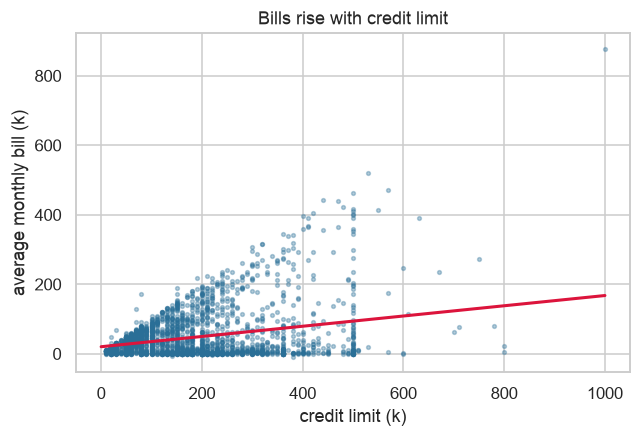

In [24]:
plot_s = df.sample(2500, random_state=3)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.scatter(plot_s["limit_k"], plot_s["avg_bill"], s=6, alpha=0.35, color="#2a6f97")
xs = np.linspace(0, df["limit_k"].max(), 50)
ax.plot(xs, m1.params["Intercept"] + m1.params["limit_k"] * xs, color="crimson", lw=2)
ax.set_xlabel("credit limit (k)"); ax.set_ylabel("average monthly bill (k)"); ax.set_title("Bills rise with credit limit")
plt.show()

**How to read the table** (this is 80% of interpreting any regression):

| Piece | Meaning |
|---|---|
| `coef` on `limit_k` | Each extra 1k of credit limit goes with this many extra k of average bill |
| `std err` | The standard error of that coefficient — its wobble |
| `P>|t|` | Test of H0: "the true coefficient is 0" (no relationship) |
| `[0.025 0.975]` | 95% CI for the coefficient |
| R-squared | Share of the *variation* in bills the model explains (0 = none, 1 = all) |

### 5.2 Multiple regression: several factors at once

In [25]:
formula = "avg_bill ~ limit_k + AGE + late_1 + C(edu_label) + C(marriage_label)"
m2 = smf.ols(formula, data=df).fit()

def tidy(model):
    ci = model.conf_int()
    return pd.DataFrame({"coef": model.params, "ci_low": ci[0], "ci_high": ci[1], "p_value": model.pvalues}).round(4)

print(f"R-squared: {m2.rsquared:.3f}   Adjusted R-squared: {m2.rsquared_adj:.3f}   F-test p-value: {fmt_p(m2.f_pvalue)}")
tidy(m2)

R-squared: 0.106   Adjusted R-squared: 0.105   F-test p-value: < 0.001


,coef,ci_low,ci_high,p_value
Intercept,0.8842,-2.8849,4.6533,0.6457
C(edu_label)[T.High school],10.9819,8.8197,13.1442,0.0000
C(edu_label)[T.Other],19.3389,13.7895,24.8883,0.0000
C(edu_label)[T.University],13.6238,12.0518,15.1958,0.0000
C(marriage_label)[T.Other],-2.6898,-8.8353,3.4557,0.3910
C(marriage_label)[T.Single],4.2152,2.6563,5.7741,0.0000
limit_k,0.1652,0.1596,0.1708,0.0000
AGE,0.1035,0.0178,0.1892,0.0179
late_1,5.7959,4.8914,6.7003,0.0000


**Interpretation habits:**
- *"Holding everything else constant"* is the magic phrase. The `late_1` coefficient is the difference for two customers who are the same on every other listed variable.
- Categorical variables (`C(edu_label)`) are compared against a **reference group** (the first alphabetically, here "Graduate school"). A coefficient of +3 means "3k more than the reference".
- **Adjusted R-squared** penalises adding useless predictors; plain R-squared can only go up.
- **Association, not causation.** Age doesn't *cause* bills; it travels with life stage.

### 5.3 Check your model before trusting it

A regression makes promises (linear pattern, evenly-spread errors, roughly normal errors). Residual plots check them. **Analogy:** a bathroom scale that is fine for light people but reads erratically for heavy ones — the *errors* shouldn't depend on the size of what you measure.

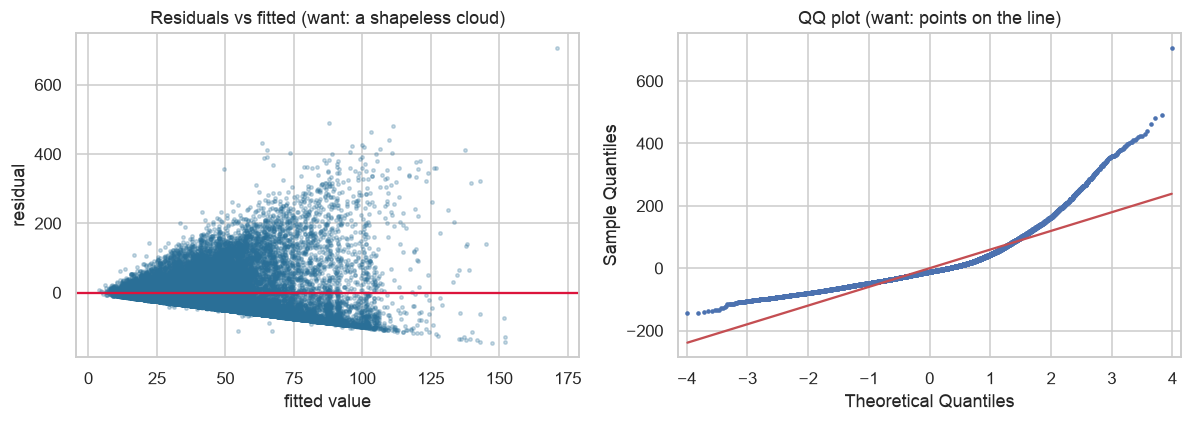

Breusch-Pagan test for uneven error spread: p < 0.001   (small p = errors fan out = assumption violated)


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(m2.fittedvalues, m2.resid, s=5, alpha=0.25, color="#2a6f97")
axes[0].axhline(0, color="crimson"); axes[0].set_xlabel("fitted value"); axes[0].set_ylabel("residual"); axes[0].set_title("Residuals vs fitted (want: a shapeless cloud)")
sm.qqplot(m2.resid, line="s", ax=axes[1], markersize=2); axes[1].set_title("QQ plot (want: points on the line)")
plt.tight_layout(); plt.show()

bp_lm, bp_p, _, _ = het_breuschpagan(m2.resid, m2.model.exog)
print(f"Breusch-Pagan test for uneven error spread: p {fmt_p(bp_p) if bp_p < 0.001 else '= ' + fmt_p(bp_p)}   (small p = errors fan out = assumption violated)")

The residuals **fan out** (bigger errors for bigger bills) and the tails are heavy. Bills are money — skewed and multiplicative. The standard fix: model the **log** of the outcome, so coefficients become **percentage** effects. (Log needs a positive outcome, so we drop the small share of customers with a zero/negative average bill.)

### 5.4 Fix: model the log of the bill

In [27]:
pos = df[df["avg_bill"] > 0]
m3 = smf.ols("np.log(avg_bill) ~ limit_k + AGE + late_1 + C(edu_label) + C(marriage_label)", data=pos).fit()
res = tidy(m3)
res["pct_effect"] = ((np.exp(res["coef"]) - 1) * 100).round(2)
print(f"Rows used: {len(pos):,}   R-squared: {m3.rsquared:.3f}")
res

Rows used: 28,929   R-squared: 0.023


,coef,ci_low,ci_high,p_value,pct_effect
Intercept,2.2137,2.1016,2.3259,0.0000,814.95
C(edu_label)[T.High school],0.4463,0.3818,0.5108,0.0000,56.25
C(edu_label)[T.Other],0.5172,0.3522,0.6823,0.0000,67.73
C(edu_label)[T.University],0.4956,0.4487,0.5426,0.0000,64.15
C(marriage_label)[T.Other],-0.0493,-0.2310,0.1325,0.5952,-4.81
C(marriage_label)[T.Single],0.1191,0.0727,0.1655,0.0000,12.65
limit_k,0.0016,0.0014,0.0017,0.0000,0.16
AGE,-0.0025,-0.0051,0.0000,0.0530,-0.25
late_1,0.1200,0.0933,0.1468,0.0000,12.75


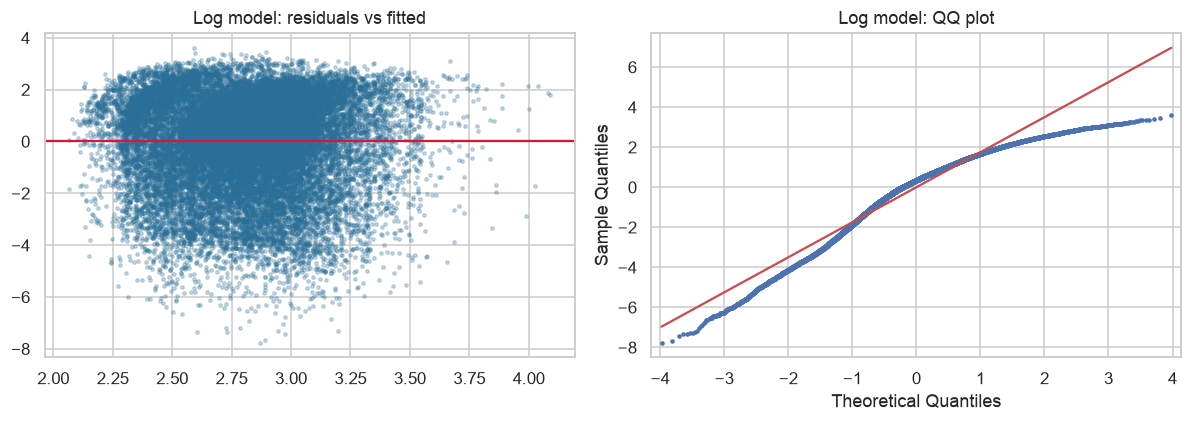

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(m3.fittedvalues, m3.resid, s=5, alpha=0.25, color="#2a6f97")
axes[0].axhline(0, color="crimson"); axes[0].set_title("Log model: residuals vs fitted")
sm.qqplot(m3.resid, line="s", ax=axes[1], markersize=2); axes[1].set_title("Log model: QQ plot")
plt.tight_layout(); plt.show()

**Better, not perfect.** The fan shape is gone, which was the main problem. A few customers with very small bills leave a long left tail — real data is rarely textbook. That is why analysts often report **robust standard errors**, which stay trustworthy when the error spread isn't perfectly even. (R-squared here is not comparable with the earlier model: the outcome changed scale.)

In [29]:
m3_robust = smf.ols("np.log(avg_bill) ~ limit_k + AGE + late_1 + C(edu_label) + C(marriage_label)", data=pos).fit(cov_type="HC3")
pd.DataFrame({"std_err_classic": m3.bse, "std_err_robust (HC3)": m3_robust.bse}).round(5).loc[["limit_k", "AGE", "late_1"]]

,std_err_classic,std_err_robust (HC3)
limit_k,0.00009,0.00009
AGE,0.00130,0.00127
late_1,0.01364,0.01237


Now `pct_effect` reads naturally, e.g. *"each extra 1k of limit is associated with about this % higher bills"* — see the plain-English summary at the end of this section.

### 5.5 Does it hold up on customers the model hasn't seen?

In [30]:
train_pos, test_pos = train_test_split(pos, test_size=0.25, random_state=42)
m_tr = smf.ols("np.log(avg_bill) ~ limit_k + AGE + late_1 + C(edu_label) + C(marriage_label)", data=train_pos).fit()
r2_train = r2_score(np.log(train_pos["avg_bill"]), m_tr.predict(train_pos))
r2_test = r2_score(np.log(test_pos["avg_bill"]), m_tr.predict(test_pos))
print(f"R-squared on training data: {r2_train:.3f}   on unseen test data: {r2_test:.3f}")

R-squared on training data: 0.025   on unseen test data: 0.018


A model that scores far better on data it has seen than on data it hasn't is **overfitting** — memorising instead of learning. Similar numbers = healthy.

### 5.6 A classic trap: multicollinearity

**Analogy — two people telling you the same story.** If two predictors carry nearly the same information, the model can't tell whose credit it is, so coefficients become unstable (wrong signs, huge standard errors). The **VIF** (variance inflation factor) flags it: above ~5-10 is a warning.

In [31]:
def vif_table(cols):
    X = sm.add_constant(df[cols])
    return pd.Series([variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])], index=cols, name="VIF").round(1)

print("Six monthly bills used together (they move in lockstep):")
print(vif_table(BILL_COLS).to_string())
print("\nOur regression predictors:")
print(vif_table(["limit_k", "AGE", "late_1"]).to_string())

Six monthly bills used together (they move in lockstep):
BILL_AMT1    10.7
BILL_AMT2    16.0
BILL_AMT3    10.8
BILL_AMT4    13.3
BILL_AMT5    15.7
BILL_AMT6     9.7

Our regression predictors:
limit_k    1.1
AGE        1.0
late_1     1.0


In [32]:
pct_per_100k = (np.exp(100 * m3.params["limit_k"]) - 1) * 100
pct_per_late = (np.exp(m3.params["late_1"]) - 1) * 100
print("SAY IT IN PLAIN ENGLISH")
print(f"Holding other factors equal, customers with a credit limit 100k higher have monthly bills about {pct_per_100k:.0f}% higher,")
print(f"and each extra month of payment delay goes with bills about {pct_per_late:.0f}% {'higher' if pct_per_late > 0 else 'lower'}.")
print(f"The model explains {m3.rsquared:.0%} of the variation in (log) bills: good for spotting trends and planning, not for predicting one person's bill.")
print("We checked the assumptions first, and fixed a fan-shaped error pattern with a log transform.")

SAY IT IN PLAIN ENGLISH
Holding other factors equal, customers with a credit limit 100k higher have monthly bills about 17% higher,
and each extra month of payment delay goes with bills about 13% higher.
The model explains 2% of the variation in (log) bills: good for spotting trends and planning, not for predicting one person's bill.
We checked the assumptions first, and fixed a fan-shaped error pattern with a log transform.


## 6. Logistic regression: predicting a yes/no

Credit risk is a **yes/no** question: will this person default? Linear regression is the wrong tool. Why?

### 6.1 Why not just use linear regression?

In [33]:
lpm = smf.ols("default ~ late_1 + utilization + limit_k", data=df).fit()   # "linear probability model"
fv = lpm.fittedvalues
print(f"A linear model of a yes/no outcome predicts 'probabilities' from {fv.min():.2f} to {fv.max():.2f}.")
print(f"Customers with impossible probabilities (<0 or >1): {int(((fv < 0) | (fv > 1)).sum()):,}")

A linear model of a yes/no outcome predicts 'probabilities' from -0.08 to 1.85.
Customers with impossible probabilities (<0 or >1): 151


Probabilities must stay between 0 and 1. Logistic regression bends the straight line into an **S-curve** that flattens near 0 and 1.

**Analogy — a dimmer switch vs. a light switch.** The output isn't "on/off"; it is *how bright* — the probability of default, smoothly rising from 0 to 1 as risk factors add up.

**Odds**, the language of logistic regression, are the same as betting odds: probability 20% -> odds 1 to 4 (0.25). The model is linear in the **log-odds**, and exponentiating a coefficient gives an **odds ratio (OR)**:
- OR = 1 -> no effect
- OR = 1.5 -> the odds of default are **50% higher** per unit increase
- OR = 0.8 -> the odds are **20% lower**

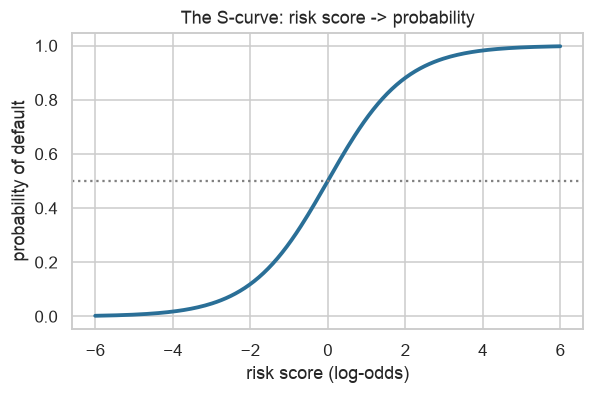

,probability,odds,log-odds
0,0.05,0.053,-2.944
1,0.20,0.250,-1.386
2,0.50,1.000,0.000
3,0.80,4.000,1.386


In [34]:
z = np.linspace(-6, 6, 200)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(z, 1 / (1 + np.exp(-z)), color="#2a6f97", lw=2.5)
ax.axhline(0.5, color="grey", ls=":"); ax.set_xlabel("risk score (log-odds)"); ax.set_ylabel("probability of default")
ax.set_title("The S-curve: risk score -> probability")
plt.show()

p = np.array([0.05, 0.20, 0.50, 0.80])
pd.DataFrame({"probability": p, "odds": (p / (1 - p)).round(3), "log-odds": np.log(p / (1 - p)).round(3)})

### 6.2 Fit the model and read it

We rescale the limit to **per 100k** so odds ratios are readable (an OR for "one extra 1k" would be 0.998 — unhelpful). Rescaling predictors for interpretability is a habit worth forming.

**A fairness decision made on purpose:** we leave `SEX` out of the model. Using gender to price or approve credit is unlawful in many places and ethically fraught; the data lets us *test* differences (Section 4) without *building them into decisions*. Age and marital status are also sensitive — in a real lender you'd check local regulation and test for disparate impact.

In [35]:
df["limit_100k"] = df["limit_k"] / 100
formula_logit = "default ~ limit_100k + AGE + late_1 + utilization + paid_ratio + C(edu_label) + C(marriage_label)"
logit = smf.logit(formula_logit, data=df).fit(disp=False)

def odds_table(model):
    ci = model.conf_int()
    return pd.DataFrame({"odds_ratio": np.exp(model.params), "ci_low": np.exp(ci[0]), "ci_high": np.exp(ci[1]), "p_value": model.pvalues}).round(3)

or_table = odds_table(logit)
print(f"Pseudo R-squared: {logit.prsquared:.3f}   |   Whole-model test p-value: {fmt_p(logit.llr_pvalue)}")
or_table

Pseudo R-squared: 0.144   |   Whole-model test p-value: < 0.001


,odds_ratio,ci_low,ci_high,p_value
Intercept,0.228,0.191,0.273,0.000
C(edu_label)[T.High school],0.933,0.848,1.026,0.153
C(edu_label)[T.Other],0.282,0.193,0.412,0.000
C(edu_label)[T.University],0.988,0.920,1.061,0.740
C(marriage_label)[T.Other],0.836,0.641,1.091,0.187
C(marriage_label)[T.Single],0.850,0.793,0.911,0.000
limit_100k,0.797,0.774,0.820,0.000
AGE,1.006,1.002,1.009,0.003
late_1,3.002,2.888,3.121,0.000
utilization,0.974,0.880,1.078,0.616


**Reading the odds-ratio table:**
- `late_1`: each extra month of payment delay multiplies the odds of default by the OR — the strongest signal, exactly as the descriptive chart suggested.
- `limit_100k`: an OR below 1 means bigger limits go with *lower* default odds (partly because lenders give bigger limits to safer customers).
- Any CI that **crosses 1** means we can't rule out "no effect" — the same idea as a p-value above 0.05.
- Odds ratios are *not* probability changes. Show probabilities to non-technical audiences:

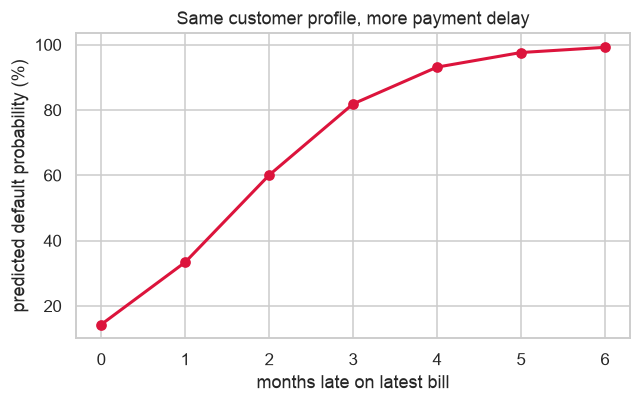

,late_1,predicted_default_prob
0,0,0.143
1,1,0.334
2,2,0.600
3,3,0.819
4,4,0.931
5,5,0.976
6,6,0.992


In [36]:
typical = pd.DataFrame({
    "late_1": np.arange(0, 7),
    "limit_100k": df["limit_100k"].median(), "AGE": df["AGE"].median(),
    "utilization": df["utilization"].median(), "paid_ratio": df["paid_ratio"].median(),
    "edu_label": df["edu_label"].mode()[0], "marriage_label": df["marriage_label"].mode()[0],
})
typical["predicted_default_prob"] = logit.predict(typical)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(typical["late_1"], typical["predicted_default_prob"] * 100, "o-", color="crimson", lw=2)
ax.set_xlabel("months late on latest bill"); ax.set_ylabel("predicted default probability (%)")
ax.set_title("Same customer profile, more payment delay")
plt.show()
typical[["late_1", "predicted_default_prob"]].round(3)

### 6.3 How good is it? Evaluate on customers the model has never seen

**Analogy — an exam with new questions.** Testing a model on the data it learned from is like handing students last year's paper with the answers. We hold back 25% of customers as a fair test.

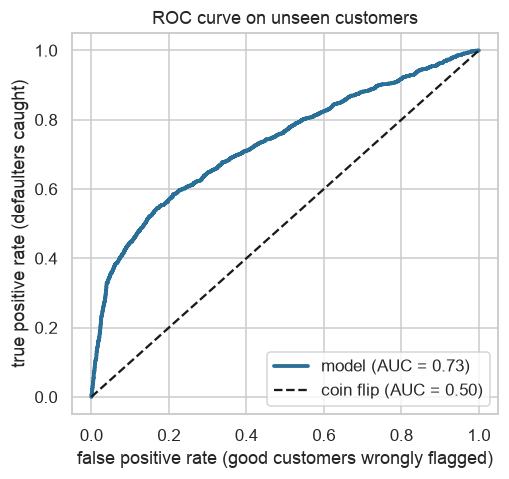

AUC = 0.732: pick one defaulter and one non-defaulter at random; the model scores the defaulter higher 73% of the time.


In [37]:
train_df, test_df = train_test_split(df, test_size=0.25, stratify=df["default"], random_state=42)
logit_tr = smf.logit(formula_logit, data=train_df).fit(disp=False)
p_test = logit_tr.predict(test_df).to_numpy()
y_test = test_df["default"].to_numpy()

auc = roc_auc_score(y_test, p_test)
fpr, tpr, _ = roc_curve(y_test, p_test)
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot(fpr, tpr, color="#2a6f97", lw=2.5, label=f"model (AUC = {auc:.2f})")
ax.plot([0, 1], [0, 1], "k--", label="coin flip (AUC = 0.50)")
ax.set_xlabel("false positive rate (good customers wrongly flagged)"); ax.set_ylabel("true positive rate (defaulters caught)")
ax.legend(loc="lower right"); ax.set_title("ROC curve on unseen customers")
plt.show()
print(f"AUC = {auc:.3f}: pick one defaulter and one non-defaulter at random; the model scores the defaulter higher {auc:.0%} of the time.")

In [38]:
# The lender's favourite view: rank customers by predicted risk, cut into 10 equal groups
test_view = pd.DataFrame({"p": p_test, "y": y_test})
test_view["risk_decile"] = pd.qcut(test_view["p"].rank(method="first"), 10, labels=False) + 1   # 10 = riskiest
decile_tbl = (test_view.groupby("risk_decile")
              .agg(customers=("y", "size"), avg_predicted=("p", "mean"), actual_default_rate=("y", "mean")).round(3))
decile_tbl

,customers,avg_predicted,actual_default_rate
risk_decile,,,
1,750,0.076,0.100
2,750,0.107,0.111
3,750,0.126,0.104
4,750,0.140,0.128
5,750,0.154,0.148
6,750,0.167,0.156
7,750,0.181,0.167
8,750,0.214,0.245
9,750,0.378,0.355


Two things to check in this table: **ranking** (default rate should climb from decile 1 to 10) and **calibration** (predicted ≈ actual — when the model says 30%, about 30% should default). Good ranking with poor calibration is fixable; poor ranking is not.

### 6.4 The same thing in scikit-learn
`statsmodels` is built for **explaining** (odds ratios, p-values, CIs). `scikit-learn` is built for **predicting** (pipelines, cross-validation, deployment). Same model, different toolbox:

In [39]:
num_cols = ["limit_100k", "AGE", "late_1", "utilization", "paid_ratio"]
cat_cols = ["edu_label", "marriage_label"]
X_tr = pd.get_dummies(train_df[num_cols + cat_cols], drop_first=True).astype(float)
X_te = pd.get_dummies(test_df[num_cols + cat_cols], drop_first=True).astype(float).reindex(columns=X_tr.columns, fill_value=0.0)

skl = Pipeline([("scale", StandardScaler()), ("lr", LogisticRegression(max_iter=1000))]).fit(X_tr, train_df["default"])
auc_skl = roc_auc_score(y_test, skl.predict_proba(X_te)[:, 1])
print(f"AUC statsmodels: {auc:.3f}   |   AUC scikit-learn: {auc_skl:.3f}   (essentially identical)")

AUC statsmodels: 0.732   |   AUC scikit-learn: 0.732   (essentially identical)


### 6.5 From probabilities to a decision: choosing the cut-off

A model gives a **probability**; the business needs an **action** (approve / decline). The cut-off is a **business decision, not a statistical one**, because the two mistakes cost different amounts:

- **Approve someone who defaults** (false negative) -> lose the money lent.
- **Decline someone who would have repaid** (false positive) -> lose the profit you'd have made.

The default cut-off of 0.5 assumes both mistakes cost the same. Here they don't. The costs below are **illustrative assumptions** — in practice you agree them with Finance/Risk.

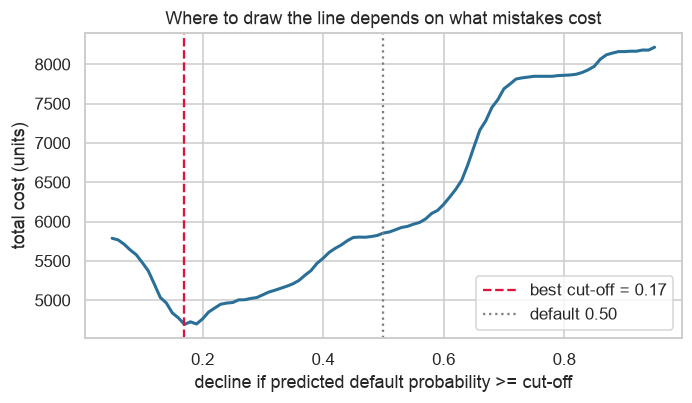

Best cut-off 0.17: approves 57% of applicants, catches 68% of would-be defaulters
Total cost - approve everyone: 8,295 | cut-off 0.50: 5,854 | best cut-off: 4,693


In [40]:
COST_APPROVE_A_DEFAULTER = 5   # units lost when we approve someone who defaults
COST_DECLINE_A_GOOD_CUSTOMER = 1   # units of profit lost when we decline someone who would have repaid

thresholds = np.linspace(0.05, 0.95, 91)
rows = []
for t in thresholds:
    decline = p_test >= t
    fn = int((~decline & (y_test == 1)).sum())   # approved but defaulted
    fp = int((decline & (y_test == 0)).sum())    # declined but would have repaid
    rows.append({"threshold": t, "cost": COST_APPROVE_A_DEFAULTER * fn + COST_DECLINE_A_GOOD_CUSTOMER * fp,
                 "approval_rate": 1 - decline.mean(), "defaulters_caught": (decline & (y_test == 1)).sum() / (y_test == 1).sum()})
cost_df = pd.DataFrame(rows)
best = cost_df.loc[cost_df["cost"].idxmin()]
best_t, approval_rate, capture = best["threshold"], best["approval_rate"], best["defaulters_caught"]

def cost_at(t):
    return cost_df.loc[(cost_df["threshold"] - t).abs().idxmin(), "cost"]
approve_all = COST_APPROVE_A_DEFAULTER * int((y_test == 1).sum())

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(cost_df["threshold"], cost_df["cost"], color="#2a6f97", lw=2)
ax.axvline(best_t, color="crimson", ls="--", label=f"best cut-off = {best_t:.2f}")
ax.axvline(0.5, color="grey", ls=":", label="default 0.50")
ax.set_xlabel("decline if predicted default probability >= cut-off"); ax.set_ylabel("total cost (units)")
ax.legend(); ax.set_title("Where to draw the line depends on what mistakes cost")
plt.show()

print(f"Best cut-off {best_t:.2f}: approves {approval_rate:.0%} of applicants, catches {capture:.0%} of would-be defaulters")
print(f"Total cost - approve everyone: {approve_all:,} | cut-off 0.50: {cost_at(0.5):,.0f} | best cut-off: {best['cost']:,.0f}")

Change the two cost numbers and re-run: if a default costs 10x instead of 5x, the best cut-off drops and the lender becomes stricter. **The Streamlit app lets you play with exactly this.**

> **Say it in plain English:** *Late payments are by far the strongest warning sign: every extra month late multiplies default odds. Ranked by the model, the riskiest tenth of applicants default at many times the rate of the safest tenth. Where we draw the approve/decline line depends on how much a bad loan costs relative to a lost customer.*

## 7. Turning results into a recommendation

Stakeholders don't want p-values; they want: **What did you find? How sure are you? What should we do? What could go wrong?** A reliable structure:

> **Finding -> Evidence -> Uncertainty -> Recommendation -> Caveat**

The cell below builds a first draft **from the numbers you actually computed**, so it stays honest when the data changes.

In [41]:
or_late = or_table.loc["late_1"]
limit_dir = "lower" if diff_limit < 0 else "higher"
top_decile, bottom_decile = decile_tbl.loc[10, "actual_default_rate"], decile_tbl.loc[1, "actual_default_rate"]

memo = f'''
MEMO: Improving credit approval decisions
------------------------------------------------------------
FINDING
  Payment history is the strongest predictor of default. Each extra month a customer is late
  multiplies their odds of defaulting by {or_late['odds_ratio']:.2f} (95% CI {or_late['ci_low']:.2f}-{or_late['ci_high']:.2f}).

EVIDENCE
  - Defaulters have credit limits {abs(diff_limit):.0f}k {limit_dir} on average (95% CI {abs(ci_limit[1]):.0f}k-{abs(ci_limit[0]):.0f}k, effect size d={abs(d_limit):.2f}).
  - On customers the model had never seen, it separates risky from safe applicants well (AUC = {auc:.2f}).
  - The riskiest 10% of applicants default {top_decile:.0%} of the time vs {bottom_decile:.0%} for the safest 10%.

UNCERTAINTY
  Estimates come from a sample; intervals above show the plausible range. Gender differs in default rate by
  about {abs(diff_sex_pp):.1f} points - statistically detectable but small, and we deliberately excluded gender from the model.

RECOMMENDATION
  Use the model as a risk-ranking tool. With the assumed cost of a bad loan at {COST_APPROVE_A_DEFAULTER}x a lost customer, a
  cut-off of {best_t:.2f} approves {approval_rate:.0%} of applicants while catching {capture:.0%} of likely defaulters.
  Agree the real cost assumptions with Finance before adopting a cut-off.

CAVEATS
  Data is a historical snapshot (Taiwan, 2005): validate on your own recent data before use. Patterns are
  associations, not proven causes. Monitor performance and fairness after launch.
'''
print(memo)


MEMO: Improving credit approval decisions
------------------------------------------------------------
FINDING
  Payment history is the strongest predictor of default. Each extra month a customer is late
  multiplies their odds of defaulting by 3.00 (95% CI 2.89-3.12).

EVIDENCE
  - Defaulters have credit limits 48k lower on average (95% CI 45k-51k, effect size d=0.37).
  - On customers the model had never seen, it separates risky from safe applicants well (AUC = 0.73).
  - The riskiest 10% of applicants default 70% of the time vs 10% for the safest 10%.

UNCERTAINTY
  Estimates come from a sample; intervals above show the plausible range. Gender differs in default rate by
  about 3.4 points - statistically detectable but small, and we deliberately excluded gender from the model.

RECOMMENDATION
  Use the model as a risk-ranking tool. With the assumed cost of a bad loan at 5x a lost customer, a
  cut-off of 0.17 approves 57% of applicants while catching 68% of likely defaulters.
  Agr

### Translation table: statistics -> plain English

| The output says | Say this instead |
|---|---|
| p = 0.003 | "If there were really no difference, we'd see a gap this big only ~3 times in 1,000. So it's unlikely to be luck." |
| 95% CI: 4 to 9 points | "We're fairly confident the true gap is somewhere between 4 and 9 points." |
| Odds ratio = 1.6 | "Each extra unit is associated with about 60% higher odds of default." |
| R-squared = 0.30 | "The model explains roughly 30% of why bills differ - useful for trends, not exact forecasts." |
| AUC = 0.77 | "Give the model one defaulter and one good customer: it ranks them correctly about 77% of the time." |
| p > 0.05 | "We didn't find convincing evidence of a difference" - **not** "there's no difference." |

### Common mistakes to avoid
1. Treating p < 0.05 as "important" (check effect size).
2. Reading "95% CI" as "95% chance the truth is inside this one interval."
3. Saying "not significant, so no effect" (absence of evidence is not evidence of absence).
4. Claiming cause from association.
5. Judging a model on the data it was trained on.
6. Testing many things and reporting only the "hits".
7. Ignoring who could be harmed by an automated decision.

## 8. Recap and take-home exercises

**One-line recap:** *Describe what happened -> quantify uncertainty (CIs) -> test whether patterns are real (hypothesis tests) -> explain drivers (linear regression) -> predict yes/no (logistic regression) -> recommend an action with caveats.*

**Try it yourself**
1. Repeat Test A for `AGE` and `utilization`. Which gap is largest by effect size (Cohen's d)?
2. In Section 3.3, change `n` from 200 to 1,000. What happens to the interval width and to the coverage?
3. Add `max_late` or `n_late_months` to the logistic model. Does AUC on the test set improve?
4. Raise `COST_APPROVE_A_DEFAULTER` to 10. How does the best cut-off and the approval rate change?
5. Remove `late_1` from the logistic model. Which variables absorb its signal, and how do their odds ratios change?
6. **Discussion:** a colleague suggests adding `SEX` because it improves AUC slightly. What would you say?

*Data: Yeh, I. C., & Lien, C. H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. Expert Systems with Applications, 36(2), 2473-2480. UCI Machine Learning Repository.*